## Comparison of My Logistic Regression and Sklearn's Logistic Regression
##### This comparison is represented by the Classification Report at the End

#### Loading Libraries

In [10]:
import matplotlib.pyplot as plt
import numpy as np

#### Loading a Pre-Built Dataset from ___sklearn.datasets Module___

In [11]:
from sklearn.datasets import load_breast_cancer

### Loading Functions for Custom Built Logistic Regression Algorithm
##### The Custom Built Algorithm Methods are saved in a separate file named: ___custom_logistic_regression.py___

In [12]:
from custom_logistic_regression import sigmoid, gradient_descent, gradient_logistic, predict

##### Separating Inputs __x__ from outputs __y__

In [ ]:
cancer = load_breast_cancer()#type:ignore

x = cancer.data#type:ignore
y = cancer.target#type:ignore

##### Scaing Features

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

##### Splitting Dataset into Training and Testing Data

In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.3)

### Predicting using _Custom Logistic Regression Model_

In [16]:
w = np.zeros((x.shape[1], ))
b = 0

w, b = gradient_descent(x_train, y_train, w, b, 0.01, 1000)

y_pred_custom = (predict(x_test, w, b) >= 0.5).astype(int)

### Predicting using _Sklearn Logistic Regression Model_

In [17]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
y_pred_sklearn = model.predict(x_test)

### Comparison of Both Models

In [18]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_sklearn))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        62
           1       0.98      0.97      0.98       109

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        62
           1       0.98      0.98      0.98       109

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



### Converting Data into a DataFrame

In [19]:
import pandas as pd
cancer_df = pd.DataFrame(cancer.data, columns = cancer.feature_names)#type: ignore
cancer_df['target'] = cancer.target#type: ignore

#### Corrrelation

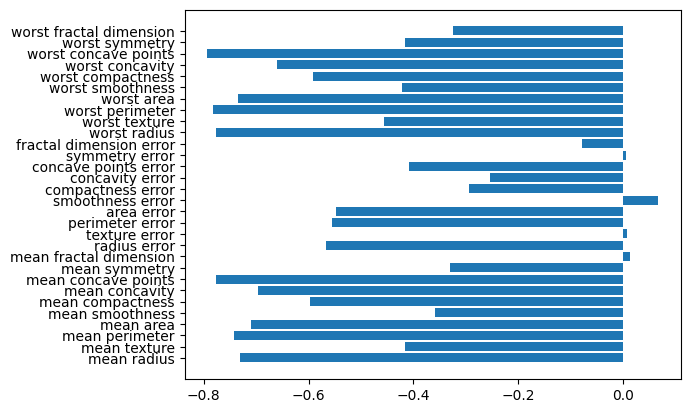

In [20]:
corr = cancer_df.corr()['target']
corr = corr[0:-1]
plt.barh(cancer_df.drop(columns=['target']).columns, width=corr)
plt.show()

### Heat-Map of Correlation

<Axes: >

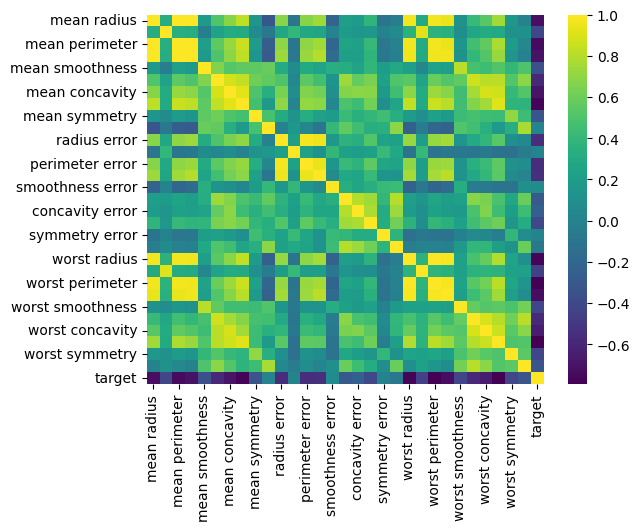

In [23]:
from seaborn import heatmap
corr = cancer_df.corr()
heatmap(cancer_df.corr(), cmap = 'viridis')